### **IMPORT LIBRARY**

In [135]:
import os, joblib, math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression   
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB      
from sklearn.svm import SVC 

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.model_selection import cross_validate
from sklearn.metrics import ( accuracy_score, precision_score, 
                             recall_score,f1_score, 
                             confusion_matrix, classification_report) 
    
import matplotlib.pyplot as plt
import seaborn as sns

### **PATH CONFIGURATION**

In [136]:
RAW_DATA = 'raw_data.csv'
FINAL_DATA = 'final_data.csv'
SCALER = 'scaler.pkl'

DATA_PATH = '../data/data2/'
MODELS_PATH = '../models/model2/'

SCALER_PATH = DATA_PATH + 'scaler/'
ENCODER_PATH = DATA_PATH + 'encoder/'

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(ENCODER_PATH, exist_ok=True)
os.makedirs(SCALER_PATH, exist_ok=True)

### **EDA PROCESS**

In [137]:
df = pd.read_csv(DATA_PATH + RAW_DATA)
print(df.shape)

(973, 15)


In [138]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [139]:
df.tail()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74
972,46,Male,88.7,1.63,166,146,66,0.75,542.0,Strength,28.8,3.5,2,1,33.38


In [140]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [142]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [143]:
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

### **DETECTING AND REMOVE DUPLICATED ROW**

In [144]:
total_data = len(df)
total_duplicates = df.duplicated().sum()
print(f"Before Dropping Duplicates:")
print(f"Total Data Row      :{total_data}")
print(f"Total Duplicate Row :{total_duplicates}")

df = df.drop_duplicates().reset_index(drop=True)

total_data_new = len(df)
total_duplicates_new = df.duplicated().sum()
print(f"\nAfter Dropping Duplicates:")
print(f"Total Data Row      :{total_data_new}")
print(f"Total Duplicate Row :{total_duplicates_new}")

Before Dropping Duplicates:
Total Data Row      :973
Total Duplicate Row :0

After Dropping Duplicates:
Total Data Row      :973
Total Duplicate Row :0


### **DETECTING AND REMOVE OUTLIER**

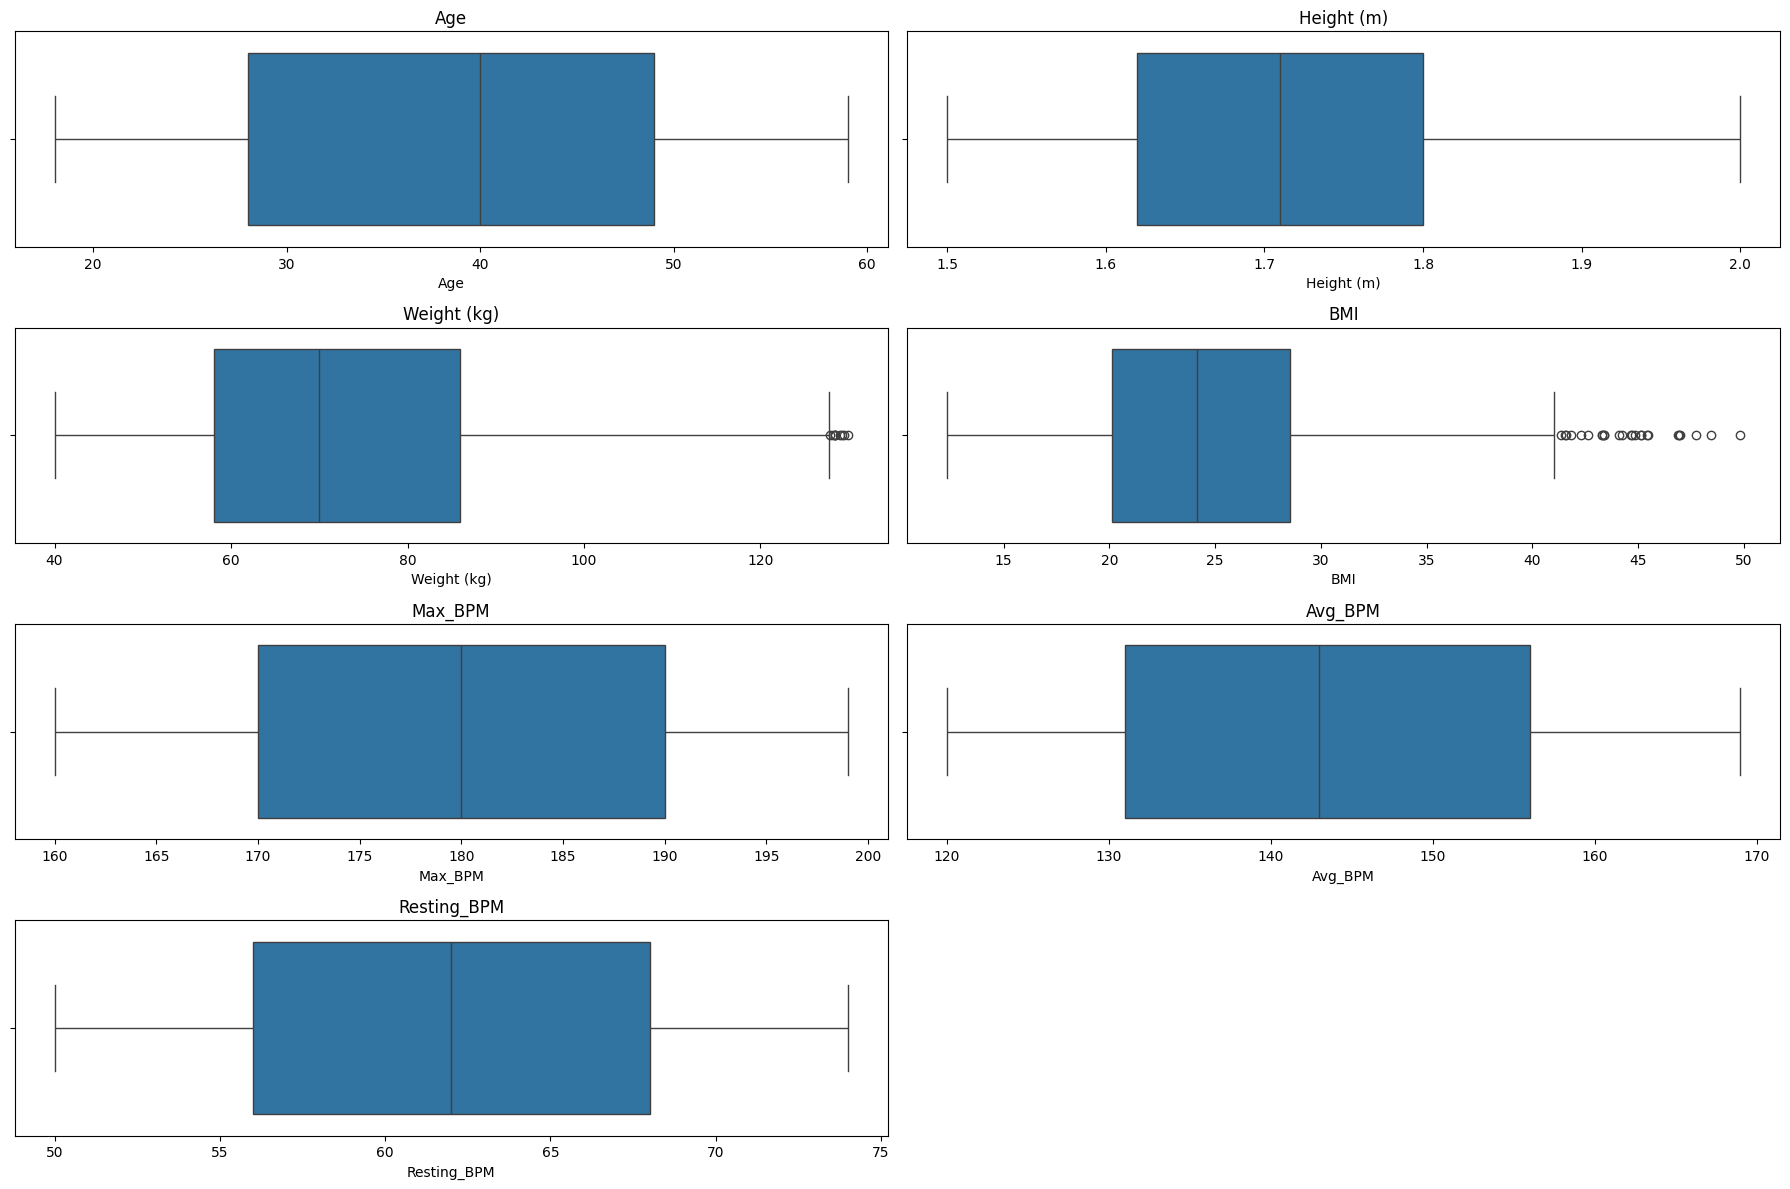

In [145]:
columns = ['Age', 'Height (m)', 'Weight (kg)', 'BMI', 'Max_BPM', 'Avg_BPM', 'Resting_BPM']
plots_per_row = 2 
n_rows = math.ceil(len(columns) / plots_per_row) 
n_cols = plots_per_row

plt.figure(figsize=(18, 3 * n_rows))
for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1) 
    sns.boxplot(x=df[col]) 
    plt.title(col, fontsize=12)

plt.tight_layout() 
plt.show()

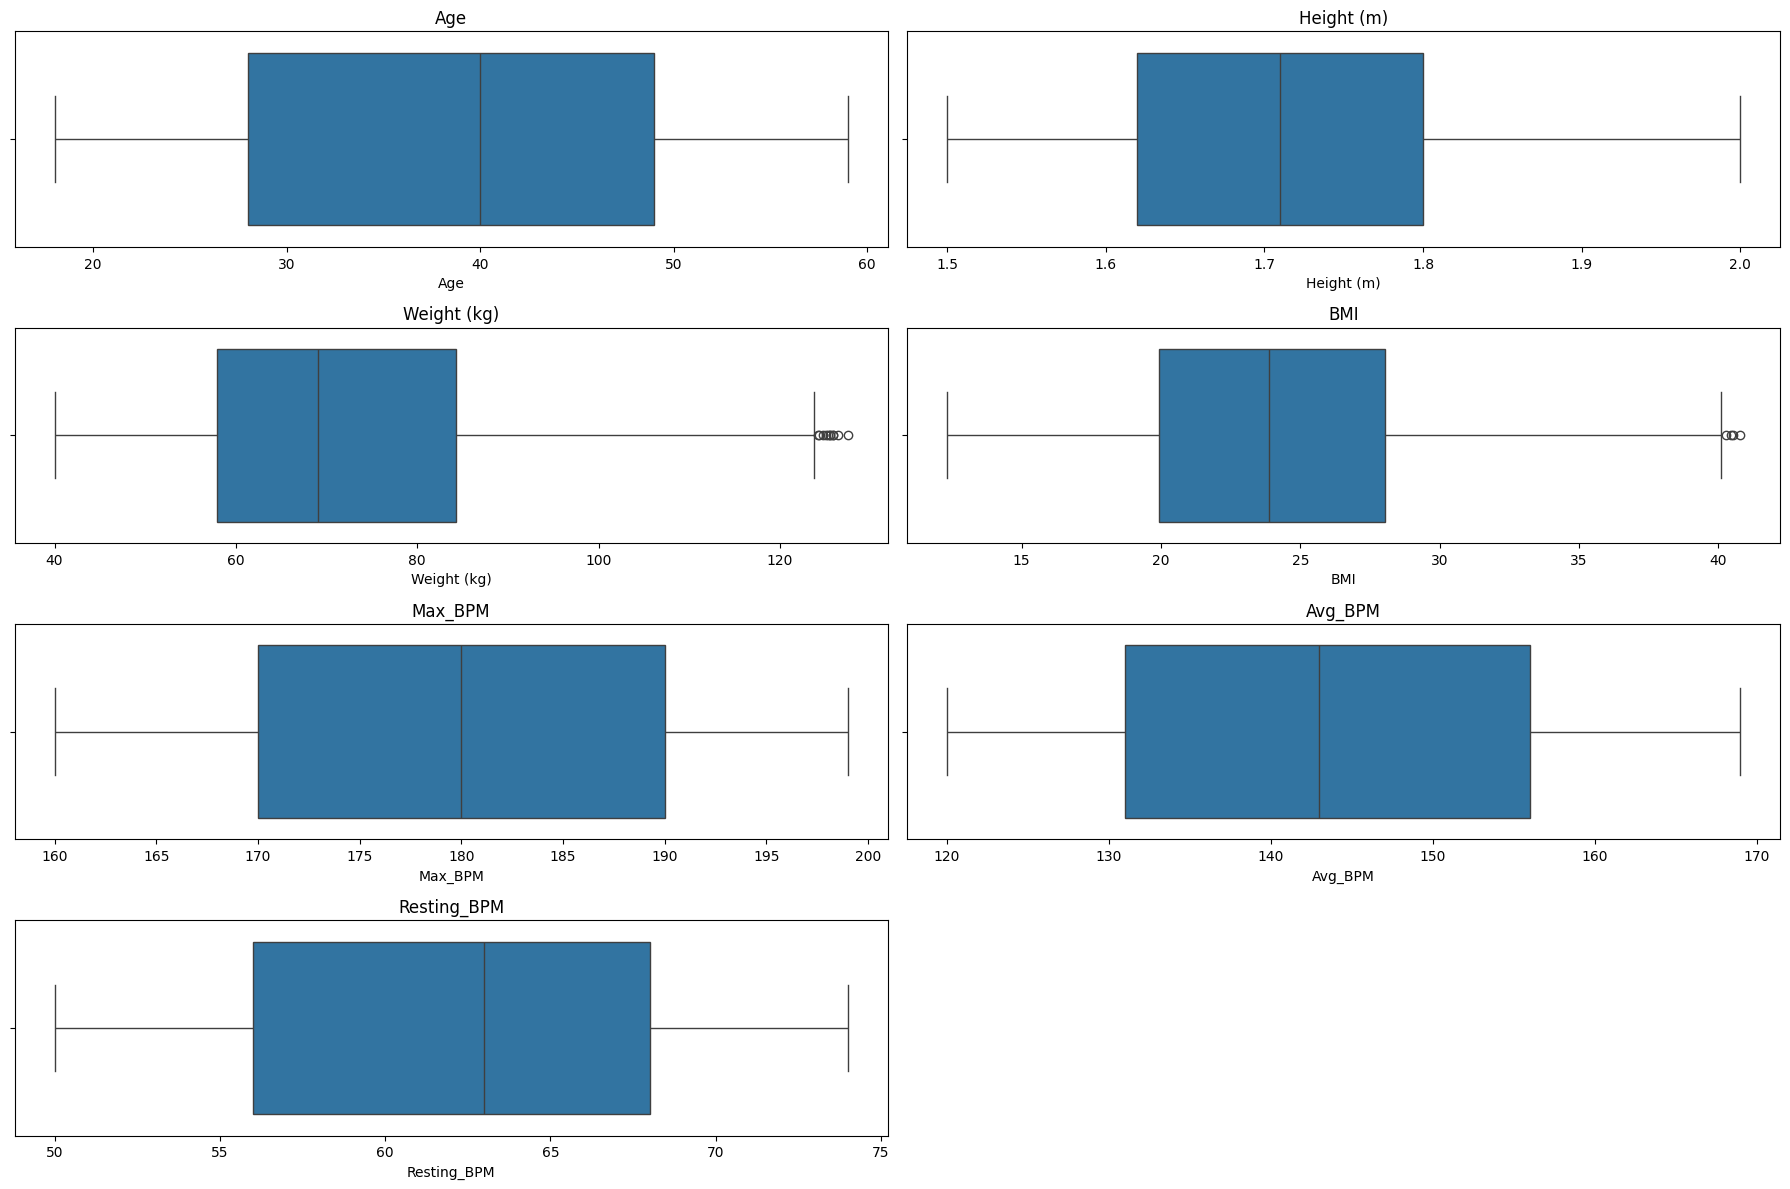

Total Data After Cleaned:  941


In [146]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & 
            (df[col] <= upper_bound)].copy()    

plt.figure(figsize=(18, 3 * n_rows))
for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1) 
    sns.boxplot(x=df[col]) 
    plt.title(col, fontsize=12)

plt.tight_layout() 
plt.show()
print("Total Data After Cleaned: ",len(df))

### **DATA ENCODING**

In [147]:
categorical_cols = ['Gender', 'Workout_Type']

label_encoders = {} 
for col in categorical_cols:
    le = LabelEncoder()
    df[col.replace(" ", "_") + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    mapping_df = pd.DataFrame({
        'label': le.classes_,
        'encoded': range(len(le.classes_))
    })
    mapping_df.to_csv(f'{ENCODER_PATH}{col.replace(" ", "_")}_encoder.csv', index=False)

df = df.drop(columns=categorical_cols)
df.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_encoded,Workout_Type_encoded
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20,1,3
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00,0,1
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71,0,0
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41,1,2
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,1,2


### **FINDING RELEVANCE AND CORRELATION**

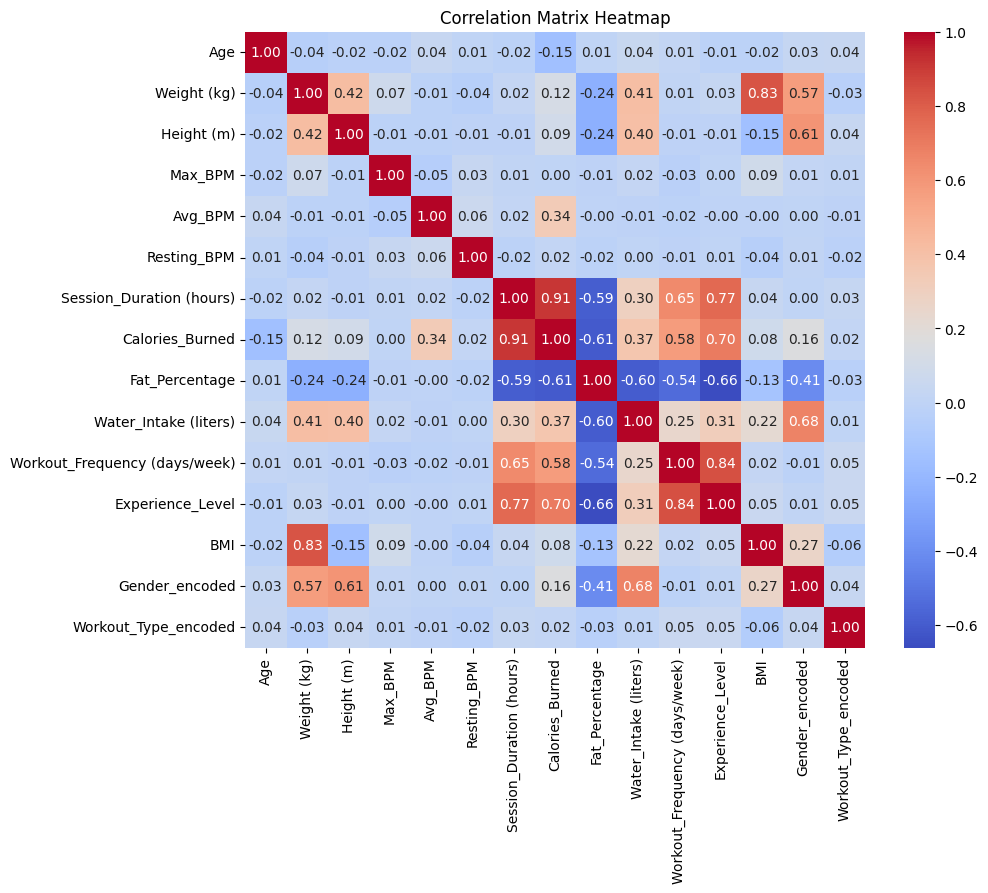

In [148]:
correlation_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

tidak ada multicolinearity

### **HANDLING MISSING DATA**

In [149]:
df.isnull().sum()

Age                              0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Gender_encoded                   0
Workout_Type_encoded             0
dtype: int64

In [150]:
df.to_csv(DATA_PATH + FINAL_DATA, index=False)

### **NORMALIZATION**

In [151]:
RANDOM_STATE = 26

In [152]:
df.columns

Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI', 'Gender_encoded', 'Workout_Type_encoded'],
      dtype='object')

In [153]:
target_columns = ['Max_BPM', 'Avg_BPM', 'Resting_BPM', 
                  'Calories_Burned', 'Water_Intake (liters)']

In [154]:
df_ready = pd.read_csv(DATA_PATH + FINAL_DATA)

X = df_ready.drop(target_columns, axis=1)
y = df_ready[target_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 658 samples
Testing set: 283 samples


In [155]:
scaler_features = df.columns.difference(target_columns).tolist()

joblib.dump(scaler_features, SCALER_PATH + "scaler_features.pkl")

['../data/data2/scaler/scaler_features.pkl']

In [156]:
scaler_features = joblib.load(SCALER_PATH + "scaler_features.pkl")

scaler = MinMaxScaler()
X_train[scaler_features] = scaler.fit_transform(X_train[scaler_features])
X_test[scaler_features] = scaler.transform(X_test[scaler_features])

df.to_csv(DATA_PATH + FINAL_DATA, index=False)
joblib.dump(scaler, SCALER_PATH + SCALER)

['../data/data2/scaler/scaler.pkl']

In [157]:
df_ready.columns

Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI', 'Gender_encoded', 'Workout_Type_encoded'],
      dtype='object')

In [158]:
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(),
    # 'SVR': SVR() # Opsional, kadang lambat kalau data besar
}

#### **COMPARE SCORE**

In [159]:
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}
results_table = []
print("====================================")
print("      5-Fold Cross Validation")
print("====================================\n")
for col in target_columns:
    print(f"\nTarget: {col}")
    y_col = y[col]
    # y_train_col = y_train[col]
    for name, model in base_models.items():
        scores = cross_validate(
            model,
            X,
            # X_train,
            y_col,
            cv=5,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )
        train_r2 = np.mean(scores["train_r2"])
        test_r2  = np.mean(scores["test_r2"])
        test_mae = -1 * np.mean(scores["test_mae"])
        print(f"  {name:20s} | Test R2: {test_r2:.4f} | Error (MAE): {test_mae:.2f}") 
        
        results_table.append({
            "target": col,
            "model": name,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "test_mae": test_mae
        })

results_df = pd.DataFrame(results_table)

print("\n\n=================================================")
print("RINGKASAN HASIL (Rata-rata Test Score per Model)")
print("=================================================")

summary = results_df.groupby("model")["test_r2"].mean().sort_values(ascending=False)
print(summary)

      5-Fold Cross Validation


Target: Max_BPM
  Linear Regression    | Test R2: -0.0161 | Error (MAE): 9.99
  Ridge                | Test R2: -0.0159 | Error (MAE): 9.98
  Lasso                | Test R2: -0.0066 | Error (MAE): 9.94
  Random Forest        | Test R2: -0.0918 | Error (MAE): 10.22

Target: Avg_BPM
  Linear Regression    | Test R2: -0.0322 | Error (MAE): 12.62
  Ridge                | Test R2: -0.0304 | Error (MAE): 12.61
  Lasso                | Test R2: -0.0201 | Error (MAE): 12.54
  Random Forest        | Test R2: -0.1232 | Error (MAE): 12.95

Target: Resting_BPM
  Linear Regression    | Test R2: -0.0210 | Error (MAE): 6.39
  Ridge                | Test R2: -0.0196 | Error (MAE): 6.39
  Lasso                | Test R2: -0.0046 | Error (MAE): 6.36
  Random Forest        | Test R2: -0.0877 | Error (MAE): 6.55

Target: Calories_Burned
  Linear Regression    | Test R2: 0.8663 | Error (MAE): 82.05
  Ridge                | Test R2: 0.8661 | Error (MAE): 81.98
  Lasso         

#### **SAVE MODEL**

In [160]:
model_name = "Random Forest"
model = base_models[model_name]

for col in target_columns:
    y_train_col = y_train[col]
    model = model
    model.fit(X_train, y_train_col)
    
    filename = f"{col}_{model_name.replace(' ', '_')}.pkl"
    joblib.dump(model, os.path.join(MODELS_PATH, filename))